In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:
os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/masks/train", exist_ok=True)

import random

for i in range(500):
    img = np.zeros((128, 128, 3), dtype=np.uint8)
    mask = np.zeros((128, 128), dtype=np.uint8)

    x1 = random.randint(30, 50)
    x2 = random.randint(80, 100)

    cv2.line(img, (x1, 128), (60, 0), (255,255,255), 2)
    cv2.line(img, (x2, 128), (90, 0), (255,255,255), 2)

    cv2.line(mask, (x1, 128), (60, 0), 255, 2)
    cv2.line(mask, (x2, 128), (90, 0), 255, 2)

    cv2.imwrite(f"dataset/images/train/{i}.jpg", img)
    cv2.imwrite(f"dataset/masks/train/{i}.png", mask)

print("✅ Dataset created")


✅ Dataset created


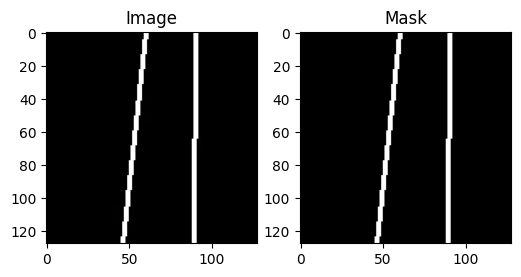

In [4]:
img = cv2.imread("dataset/images/train/0.jpg")
mask = cv2.imread("dataset/masks/train/0.png", 0)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.show()


In [5]:
class LaneDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(img_dir)
        self.transform = T.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(
            self.mask_dir, img_name.replace(".jpg", ".png")
        )

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (128,128))

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (128,128))
        mask = mask / 255.0

        image = self.transform(image)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


In [6]:
train_dataset = LaneDataset(
    "dataset/images/train",
    "dataset/masks/train"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

print("Total samples:", len(train_dataset))


Total samples: 500


In [7]:
img, mask = train_dataset[0]
print(img.shape, mask.shape)


torch.Size([3, 128, 128]) torch.Size([1, 128, 128])


In [8]:
class LaneCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


In [9]:
model = LaneCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [10]:
epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")


Epoch 1/15 | Loss: 28.3067
Epoch 2/15 | Loss: 6.3327
Epoch 3/15 | Loss: 1.9210
Epoch 4/15 | Loss: 0.7441
Epoch 5/15 | Loss: 0.5643
Epoch 6/15 | Loss: 0.4428
Epoch 7/15 | Loss: 0.3416
Epoch 8/15 | Loss: 0.2697
Epoch 9/15 | Loss: 0.2164
Epoch 10/15 | Loss: 0.1708
Epoch 11/15 | Loss: 0.1392
Epoch 12/15 | Loss: 0.1139
Epoch 13/15 | Loss: 0.0938
Epoch 14/15 | Loss: 0.0770
Epoch 15/15 | Loss: 0.0621


In [11]:
torch.save(model.state_dict(), "lane_detection_cnn.pt")
print(" Model saved")


 Model saved


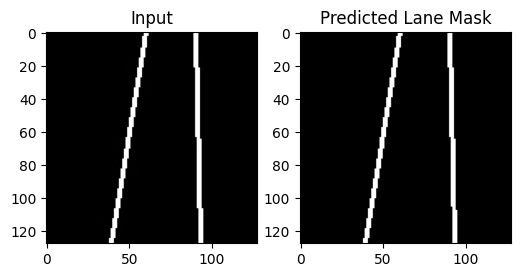

In [12]:
model.eval()

img = cv2.imread("dataset/images/train/1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (128,128))
img_tensor = T.ToTensor()(img).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(img_tensor)

mask = (pred.squeeze().cpu().numpy() > 0.5).astype("uint8")

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Predicted Lane Mask")
plt.show()
